# Blockwise over-relaxation of Sinkhorn iterations

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2025 Gabriel Peyré. Released under the MIT License; see the repository `LICENSE` file.

This notebook generates `fig:sinkhorn-overrelaxation` and illustrates blockwise over-relaxation at the small entropic scale $\varepsilon=10^{-2}$. The experiment compares marginal-residual rates measured from the nonlinear iterations with the exact local spectral prediction.

In [1]:
# --- OT4ML lightweight Colab bootstrap: one shared core, no repository clone.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import sys as _OT4ML_sys
import urllib.request as _OT4ML_urllib_request

_OT4ML_MPLCONFIG = _OT4ML_Path(
    _OT4ML_os.environ.get(
        "MPLCONFIGDIR",
        _OT4ML_Path(_OT4ML_os.environ.get("TMPDIR", "/tmp")) / "mpl-ot4ml",
    )
)
_OT4ML_MPLCONFIG.mkdir(parents=True, exist_ok=True)
_OT4ML_os.environ["MPLCONFIGDIR"] = str(_OT4ML_MPLCONFIG)


def _ot4ml_find_core():
    """Locate the single shared figure core in a local checkout."""
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        for candidate in (base / "notebooks-figures" / "figure_style.py", base / "figure_style.py"):
            if candidate.exists():
                return candidate
    return None


def _ot4ml_download_core(target):
    """Download only the shared figure core, never the full repository."""
    target.parent.mkdir(parents=True, exist_ok=True)
    urls = (
        "https://raw.githubusercontent.com/gpeyre/ot4ml/main/notebooks-figures/figure_style.py",
        "https://www.gpeyre.com/ot4ml/notebooks-figures/figure_style.py",
    )
    errors = []
    for url in urls:
        try:
            with _OT4ML_urllib_request.urlopen(url, timeout=30) as response:
                target.write_bytes(response.read())
            return target
        except Exception as error:
            errors.append(f"{url}: {error}")
    raise RuntimeError("Unable to download the OT4ML figure core.\n" + "\n".join(errors))


_OT4ML_CORE = _ot4ml_find_core()
if _OT4ML_CORE is None:
    _OT4ML_CORE = _ot4ml_download_core(
        _OT4ML_Path("/content/ot4ml-figure-runtime/notebooks-figures/figure_style.py")
    )

_OT4ML_SPEC = _OT4ML_importlib_util.spec_from_file_location("figure_style", _OT4ML_CORE)
if _OT4ML_SPEC is None or _OT4ML_SPEC.loader is None:
    raise RuntimeError(f"Cannot load OT4ML figure core from {_OT4ML_CORE}")
_OT4ML_STYLE = _OT4ML_importlib_util.module_from_spec(_OT4ML_SPEC)
_OT4ML_sys.modules["figure_style"] = _OT4ML_STYLE
_OT4ML_SPEC.loader.exec_module(_OT4ML_STYLE)

_OT4ML_PACKAGES = (
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
    ("scipy", "scipy"),
    ("IPython", "ipython"),
)
_OT4ML_REQUIRED_FILES = (

)
ROOT = _OT4ML_STYLE.configure_notebook(
    packages=_OT4ML_PACKAGES,
    required_files=_OT4ML_REQUIRED_FILES,
)
FIGROOT = ROOT / "notebooks-figures"
NOTEBOOK_DIR = FIGROOT

In [2]:
from pathlib import Path
import logging

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize, to_rgb
from scipy.special import logsumexp

from figure_style import (
    BLUE,
    GRAY,
    LIGHT_GRAY,
    ORANGE,
    RED,
    VIOLET,
    box_axes,
    canonical_matching_clouds,
    draw_point_clouds,
    figure_dir,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

logging.getLogger("fontTools").setLevel(logging.ERROR)
setup_matplotlib()

## Canonical discrete transport problem

For uniform histograms $a$ and $b$ on the two point clouds, the entropic coupling is represented relative to $a\otimes b$ as
$$
P_{ij}=a_i b_j\exp\!\left(\frac{f_i+g_j-C_{ij}}{\varepsilon}\right),
\qquad C_{ij}=\lVert x_i-y_j\rVert^2.
$$
The small value of $\varepsilon$ makes the limiting plan visually close to a sparse assignment while preserving strict positivity.

In [3]:
# Construct two reproducible planar point clouds with uniform masses.
source, target, _ = canonical_matching_clouds(seed=2027, n_source=36)
a = np.full(len(source), 1.0 / len(source))
b = np.full(len(target), 1.0 / len(target))
C = np.sum((source[:, None, :] - target[None, :, :]) ** 2, axis=2)
epsilon = 1.0e-2

## Stable over-relaxed Sinkhorn cycles

A complete relaxed cycle extrapolates each potential toward its exact soft $c$-transform:
$$
f^{(\ell+1)}=(1-\omega)f^{(\ell)}+\omega\,(g^{(\ell)})^{\bar c,\varepsilon},
\qquad
g^{(\ell+1)}=(1-\omega)g^{(\ell)}+\omega\,(f^{(\ell+1)})^{c,\varepsilon}.
$$
Thus $\omega=1$ is ordinary Sinkhorn, $0<\omega<1$ is damping, and $1<\omega<2$ is over-relaxation. All computations are carried out in log coordinates to remain stable at small temperature.

In [4]:
def log_coupling(f, g, cost, a, b, epsilon):
    """Return the log-density of the current coupling matrix.

    The matrix is represented relative to the product measure ``a tensor b``:
    ``P_ij = a_i b_j exp((f_i + g_j - C_ij) / epsilon)``.

    Args:
        f: Current source potential, with shape ``(n,)``.
        g: Current target potential, with shape ``(m,)``.
        cost: Pairwise cost matrix, with shape ``(n, m)``.
        a: Positive source histogram of length ``n``.
        b: Positive target histogram of length ``m``.
        epsilon: Positive entropic regularization strength.

    Returns:
        Matrix containing the logarithms of all coupling entries.
    """
    return (
        np.log(a)[:, None]
        + np.log(b)[None, :]
        + (f[:, None] + g[None, :] - cost) / epsilon
    )


def marginal_violation(log_plan, a, b):
    """Compute the standard averaged L1 marginal violation.

    Args:
        log_plan: Logarithms of the current coupling entries.
        a: Prescribed source histogram.
        b: Prescribed target histogram.

    Returns:
        Half the sum of the L1 row- and column-marginal defects.
    """
    row_marginal = np.exp(logsumexp(log_plan, axis=1))
    column_marginal = np.exp(logsumexp(log_plan, axis=0))
    return 0.5 * (
        np.abs(row_marginal - a).sum()
        + np.abs(column_marginal - b).sum()
    )


def relaxed_sinkhorn(
    cost,
    a,
    b,
    epsilon,
    omega,
    n_cycles,
    *,
    f_initial=None,
    g_initial=None,
):
    """Run blockwise over-relaxed Sinkhorn cycles in log coordinates.

    Each half-step extrapolates the current potential toward its exact soft
    c-transform by the factor ``omega``. Thus ``omega=1`` is ordinary
    Sinkhorn, while ``1 < omega < 2`` is over-relaxation.

    Args:
        cost: Pairwise cost matrix of shape ``(n, m)``.
        a: Positive source histogram of length ``n``.
        b: Positive target histogram of length ``m``.
        epsilon: Positive entropic regularization strength.
        omega: Relaxation factor in the interval ``[0, 2]``.
        n_cycles: Number of complete source/target updates.
        f_initial: Optional initial source potential.
        g_initial: Optional initial target potential.

    Returns:
        Final source potential, final target potential, and the marginal
        violation recorded before every cycle and after the final cycle.
    """
    if not 0.0 <= omega <= 2.0:
        raise ValueError("omega must belong to [0, 2]")

    f = np.zeros(len(a)) if f_initial is None else np.array(f_initial, copy=True)
    g = np.zeros(len(b)) if g_initial is None else np.array(g_initial, copy=True)
    errors = np.empty(n_cycles + 1)

    for cycle in range(n_cycles + 1):
        errors[cycle] = marginal_violation(
            log_coupling(f, g, cost, a, b, epsilon), a, b
        )
        if cycle == n_cycles:
            break

        f_target = -epsilon * logsumexp(
            np.log(b)[None, :] + (g[None, :] - cost) / epsilon,
            axis=1,
        )
        f = (1.0 - omega) * f + omega * f_target

        g_target = -epsilon * logsumexp(
            np.log(a)[:, None] + (f[:, None] - cost) / epsilon,
            axis=0,
        )
        g = (1.0 - omega) * g + omega * g_target

        # Fix the additive gauge without changing the represented coupling.
        shift = np.dot(a, f)
        f -= shift
        g += shift

    return f, g, errors


def solve_sinkhorn(cost, a, b, epsilon, tolerance=1.0e-13, max_cycles=20_000):
    """Solve the entropic problem accurately with ordinary Sinkhorn.

    Args:
        cost: Pairwise cost matrix.
        a: Positive source histogram.
        b: Positive target histogram.
        epsilon: Positive entropic regularization strength.
        tolerance: Required averaged L1 marginal violation.
        max_cycles: Maximum number of complete Sinkhorn cycles.

    Returns:
        Optimal source potential, target potential, and coupling matrix.

    Raises:
        RuntimeError: If the requested marginal tolerance is not reached.
    """
    f = np.zeros(len(a))
    g = np.zeros(len(b))
    for _ in range(max_cycles):
        f, g, errors = relaxed_sinkhorn(
            cost, a, b, epsilon, 1.0, 1, f_initial=f, g_initial=g
        )
        if errors[-1] <= tolerance:
            break
    else:
        raise RuntimeError("Sinkhorn did not reach the requested tolerance")

    plan = np.exp(log_coupling(f, g, cost, a, b, epsilon))
    return f, g, plan

## Exact local contraction factor

Let $\sigma_\varepsilon$ be the second singular value of the normalized optimal coupling $P_\varepsilon/\sqrt{ab^\top}$. On a singular mode $s$, one relaxed cycle has characteristic polynomial
$$
z^2-\bigl(2(1-\omega)+\omega^2s^2\bigr)z+(1-\omega)^2.
$$
The worst centered mode is $s=\sigma_\varepsilon$. Its spectral radius gives the theoretical one-cycle factor $r_{\rm loc}(\omega)$, and the optimum is
$$
\omega_\star=\frac{2}{1+\sqrt{1-\sigma_\varepsilon^2}},
\qquad r_{\rm loc}(\omega_\star)=\omega_\star-1.
$$
The numerical factor $\widehat r_{\rm marg}(\omega)$ used below is estimated independently from the marginal residuals. Over the last iterates above roundoff, an affine least-squares fit of $\log r_\ell$ against $\ell$ has slope $\widehat s_\omega$, and $\widehat r_{\rm marg}(\omega)=e^{\widehat s_\omega}$.


In [5]:
def maximal_correlation(plan, a, b):
    """Compute the nontrivial maximal correlation of a coupling.

    Args:
        plan: Coupling matrix with marginals ``a`` and ``b``.
        a: Positive source histogram.
        b: Positive target histogram.

    Returns:
        Second singular value of the normalized coupling matrix.
    """
    normalized_plan = plan / np.sqrt(a[:, None] * b[None, :])
    singular_values = np.linalg.svd(normalized_plan, compute_uv=False)
    if not np.isclose(singular_values[0], 1.0, atol=2.0e-10):
        raise RuntimeError("The normalized coupling has an invalid leading mode")
    return float(singular_values[1])


def local_relaxed_rate(omega, sigma):
    """Evaluate the exact local contraction factor of relaxed Sinkhorn.

    Args:
        omega: Scalar or array of block-relaxation factors.
        sigma: Maximal correlation of the optimal entropic coupling.

    Returns:
        Spectral radius of the centered two-block linearization.
    """
    omega = np.asarray(omega, dtype=float)
    trace = 2.0 * (1.0 - omega) + omega**2 * sigma**2
    determinant = (1.0 - omega) ** 2
    discriminant = trace**2 - 4.0 * determinant

    rate = np.empty_like(omega)
    real_roots = discriminant >= 0.0
    root_gap = np.sqrt(np.maximum(discriminant, 0.0))
    root_plus = 0.5 * (trace + root_gap)
    root_minus = 0.5 * (trace - root_gap)
    rate[real_roots] = np.maximum(
        np.abs(root_plus[real_roots]), np.abs(root_minus[real_roots])
    )
    rate[~real_roots] = np.abs(1.0 - omega[~real_roots])

    # The remaining constant nongauge mode has factor (1-omega)^2.
    return np.maximum(rate, determinant)


def estimate_marginal_rate(errors, *, residual_floor=2.0e-12, max_points=80):
    """Estimate the asymptotic contraction factor from residual iterates.

    A least-squares line is fitted to ``log(errors)`` over the last available
    iterates above the numerical floor. Its exponential slope estimates the
    contraction factor per complete relaxed Sinkhorn cycle.

    Args:
        errors: Positive marginal residuals indexed by complete cycles.
        residual_floor: Smallest residual retained in the regression.
        max_points: Maximum number of tail iterates used in the fit.

    Returns:
        Estimated contraction factor and the indices used in the regression.

    Raises:
        RuntimeError: If fewer than eight reliable residuals are available.
    """
    errors = np.asarray(errors, dtype=float)
    indices = np.flatnonzero(np.isfinite(errors) & (errors > residual_floor))
    if indices.size < 8:
        raise RuntimeError("Too few residuals remain above the numerical floor")
    indices = indices[-min(max_points, indices.size):]
    slope, _ = np.polyfit(indices, np.log(errors[indices]), deg=1)
    return float(np.exp(slope)), indices


## Common warm start and diagnostics

The theorem is local, so all five runs branch from the same state obtained after 300 ordinary Sinkhorn cycles. This removes the potentially large global transient of aggressive over-relaxation. The first two values compare damping and ordinary Sinkhorn, while the last three probe the predicted optimum and two more aggressive parameters between $\omega_\star$ and $2$.


In [6]:
# Compute the limiting coupling and the local spectral quantities.
f_star, g_star, plan = solve_sinkhorn(C, a, b, epsilon)
sigma = maximal_correlation(plan, a, b)
omega_star = 2.0 / (1.0 + np.sqrt(1.0 - sigma**2))

# Enter the local regime once, then branch all comparisons from the same state.
warmup_cycles = 300
f_warm, g_warm, warmup_errors = relaxed_sinkhorn(
    C, a, b, epsilon, 1.0, warmup_cycles
)
selected_omegas = np.array(
    [0.5, 1.0, omega_star, 0.5 * (omega_star + 2.0), 1.97]
)
comparison_cycles = 220
error_curves = []
for omega in selected_omegas:
    _, _, errors = relaxed_sinkhorn(
        C,
        a,
        b,
        epsilon,
        omega,
        comparison_cycles,
        f_initial=f_warm,
        g_initial=g_warm,
    )
    error_curves.append(errors)

# Estimate the contraction factors directly from the marginal-residual tails.
empirical_rates = np.array(
    [estimate_marginal_rate(errors)[0] for errors in error_curves]
)
theoretical_rates = local_relaxed_rate(selected_omegas, sigma)

# Numerical consistency checks for both the coupling and the rate formula.
plan_error = 0.5 * (
    np.abs(plan.sum(axis=1) - a).sum()
    + np.abs(plan.sum(axis=0) - b).sum()
)
assert plan_error < 2.0e-12
assert np.isclose(local_relaxed_rate(1.0, sigma), sigma**2, rtol=1.0e-11)
assert np.isclose(
    local_relaxed_rate(omega_star, sigma), omega_star - 1.0, rtol=1.0e-10
)
assert all(np.all(np.isfinite(curve)) for curve in error_curves)
assert np.all((0.0 < empirical_rates) & (empirical_rates < 1.0))

print(f"epsilon             = {epsilon:.3g}")
print(f"maximal correlation = {sigma:.6f}")
print(f"optimal omega        = {omega_star:.6f}")
print(f"ordinary rate        = {sigma**2:.6f}")
print(f"optimal local rate   = {omega_star - 1.0:.6f}")
print(f"warm-start residual  = {warmup_errors[-1]:.3e}")
print("\nomega    theoretical rate    measured residual rate")
for omega, theoretical, empirical in zip(
    selected_omegas, theoretical_rates, empirical_rates
):
    print(f"{omega:5.3f}        {theoretical:8.6f}                {empirical:8.6f}")

epsilon             = 0.01
maximal correlation = 0.992810
optimal omega        = 1.786194
ordinary rate        = 0.985672
optimal local rate   = 0.786194
warm-start residual  = 2.481e-04

omega    theoretical rate    measured residual rate
0.500        0.995216                0.995221
1.000        0.985672                0.985701
1.786        0.786194                0.800253
1.893        0.893097                0.893725
1.970        0.970000                0.972037


## One-line figure

The left panel retains only the significant entries of the limiting plan and makes their widths proportional to transported mass. The middle panel plots the standard averaged marginal residual
$$
r_\ell=\frac12\left(\lVert P^{(\ell)}\mathbf 1-a\rVert_1+\lVert (P^{(\ell)})^\top\mathbf 1-b\rVert_1\right).
$$
Curves stop once they reach numerical roundoff. On the right, the continuous curve is the theoretical gain $1-r_{\rm loc}(\omega)$ of one linearized relaxed cycle. Filled circles mark its values at the five displayed parameters, whereas crosses show the independently fitted gains $1-\widehat r_{\rm marg}(\omega)$ from the nonlinear marginal residuals.


In [7]:
def draw_weighted_plan(ax, source, target, plan, threshold_fraction=0.35):
    """Draw only significant coupling edges with mass-proportional widths.

    Args:
        ax: Matplotlib axes receiving the geometric panel.
        source: Source point cloud of shape ``(n, 2)``.
        target: Target point cloud of shape ``(m, 2)``.
        plan: Coupling matrix between the two clouds.
        threshold_fraction: Fraction of the largest entry used as cutoff.

    Returns:
        Number of displayed coupling segments.
    """
    cutoff = threshold_fraction * float(plan.max())
    indices = np.argwhere(plan >= cutoff)
    masses = plan[indices[:, 0], indices[:, 1]]
    relative_mass = masses / masses.max()
    segments = [[source[i], target[j]] for i, j in indices]
    violet = np.asarray(to_rgb(VIOLET))
    colors = [(*violet, 0.18 + 0.70 * mass) for mass in relative_mass]
    widths = 0.22 + 2.30 * relative_mass
    ax.add_collection(
        LineCollection(
            segments,
            colors=colors,
            linewidths=widths,
            capstyle="round",
            zorder=1,
        )
    )
    return len(segments)


def omega_label(omega, omega_star):
    """Format a concise legend label for a relaxation factor.

    Args:
        omega: Relaxation factor to format.
        omega_star: The theoretically optimal local factor.

    Returns:
        LaTeX-ready legend label.
    """
    if np.isclose(omega, omega_star):
        return rf"$\omega_\star={omega:.2f}$"
    if np.isclose(omega, round(omega)):
        return rf"$\omega={omega:.0f}$"
    return rf"$\omega={omega:.2f}$"

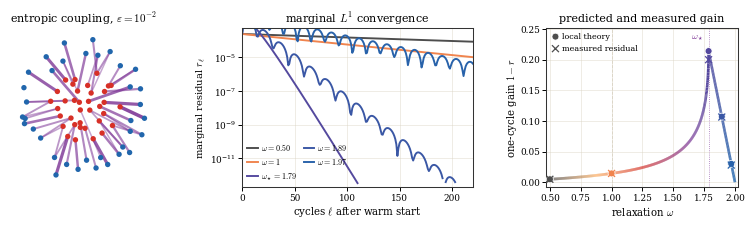

Displayed 47 coupling segments above the mass threshold.


In [8]:
omega_cmap = LinearSegmentedColormap.from_list(
    "ot4ml_omega", [GRAY, ORANGE, RED, VIOLET, BLUE]
)
omega_norm = Normalize(vmin=0.5, vmax=2.0)
selected_colors = [omega_cmap(omega_norm(omega)) for omega in selected_omegas]

fig = plt.figure(figsize=(7.55, 2.28))
grid = fig.add_gridspec(
    1,
    3,
    width_ratios=(1.05, 1.42, 1.18),
    left=0.015,
    right=0.995,
    bottom=0.20,
    top=0.90,
    wspace=0.37,
)
ax_plan, ax_error, ax_rate = [fig.add_subplot(grid[0, index]) for index in range(3)]

# Left: the small-temperature entropic coupling.
shown_edges = draw_weighted_plan(ax_plan, source, target, plan)
draw_point_clouds(ax_plan, source, target, base_size=15.0, zorder=3)
x_limits, y_limits = padded_limits(np.vstack([source, target]), pad=0.09)
ax_plan.set_xlim(*x_limits)
ax_plan.set_ylim(*y_limits)
ax_plan.set_aspect("equal")
remove_axes(ax_plan)
ax_plan.set_title(r"entropic coupling, $\varepsilon=10^{-2}$", fontsize=8.0, pad=4.0)

# Middle: nonlinear marginal convergence from a common local warm start.
cycles = np.arange(comparison_cycles + 1)
residual_floor = 3.0e-13
for omega, errors, color in zip(selected_omegas, error_curves, selected_colors):
    ax_error.plot(
        cycles,
        np.where(errors >= residual_floor, errors, np.nan),
        color=color,
        lw=1.38,
        label=omega_label(omega, omega_star),
    )
ax_error.set_yscale("log")
ax_error.set_xlim(0, comparison_cycles)
ax_error.set_ylim(2.0e-13, 6.0e-4)
ax_error.set_xlabel(r"cycles $\ell$ after warm start", fontsize=7.3, labelpad=2.0)
ax_error.set_ylabel(r"marginal residual $r_\ell$", fontsize=7.2, labelpad=1.5)
ax_error.set_title(r"marginal $L^1$ convergence", fontsize=8.0, pad=4.0)
ax_error.tick_params(axis="both", labelsize=6.4, pad=1.4)
ax_error.grid(True, which="major", color=LIGHT_GRAY, lw=0.43, alpha=0.70)
ax_error.legend(
    loc="lower left",
    ncol=2,
    fontsize=5.8,
    frameon=False,
    handlelength=1.35,
    columnspacing=0.75,
    handletextpad=0.35,
    borderaxespad=0.25,
)
box_axes(ax_error)

# Right: theoretical spectral gain and rates measured from residual tails.
omega_grid = np.linspace(0.5, 2.0, 1201)
rate_grid = local_relaxed_rate(omega_grid, sigma)
gain_grid = 1.0 - rate_grid
curve_points = np.column_stack([omega_grid, gain_grid])
curve_segments = np.stack([curve_points[:-1], curve_points[1:]], axis=1)
ax_rate.add_collection(
    LineCollection(
        curve_segments,
        cmap=omega_cmap,
        norm=omega_norm,
        array=0.5 * (omega_grid[:-1] + omega_grid[1:]),
        linewidth=1.90,
        zorder=2,
    )
)
theoretical_gains = 1.0 - theoretical_rates
empirical_gains = 1.0 - empirical_rates
ax_rate.scatter(
    selected_omegas,
    theoretical_gains,
    s=25,
    c=selected_colors,
    edgecolors="white",
    linewidths=0.55,
    zorder=4,
    label="local theory",
)
ax_rate.scatter(
    selected_omegas,
    empirical_gains,
    s=25,
    c=selected_colors,
    marker="x",
    linewidths=0.90,
    zorder=5,
    label="measured residual",
)
ax_rate.axvline(1.0, color=LIGHT_GRAY, lw=0.60, ls="--", zorder=0)
ax_rate.axvline(omega_star, color=VIOLET, lw=0.58, ls=":", alpha=0.75, zorder=0)
ax_rate.text(
    omega_star - 0.035,
    1.0 - local_relaxed_rate(omega_star, sigma) + 0.013,
    r"$\omega_\star$",
    color=VIOLET,
    fontsize=6.6,
    ha="right",
    va="bottom",
)
ax_rate.set_xlim(0.47, 2.025)
ax_rate.set_ylim(-0.008, 1.18 * gain_grid.max())
ax_rate.set_xlabel(r"relaxation $\omega$", fontsize=7.3, labelpad=2.0)
ax_rate.set_ylabel(r"one-cycle gain $1-r$", fontsize=7.3, labelpad=1.0)
ax_rate.set_title("predicted and measured gain", fontsize=8.0, pad=4.0)
ax_rate.tick_params(axis="both", labelsize=6.4, pad=1.4)
ax_rate.grid(True, which="major", color=LIGHT_GRAY, lw=0.43, alpha=0.70)
ax_rate.legend(
    loc="upper left",
    fontsize=5.8,
    frameon=False,
    handlelength=1.0,
    handletextpad=0.35,
    borderaxespad=0.25,
)
box_axes(ax_rate)

out = figure_dir("sinkhorn-overrelaxation")
save_pdf(fig, out / "overview.pdf", pad_inches=0.025)
thumbnail = ROOT / "notebooks-figures" / "thumbnails" / "sinkhorn-overrelaxation.png"
fig.savefig(thumbnail, dpi=180, bbox_inches="tight", pad_inches=0.035)
plt.show()
print(f"Displayed {shown_edges} coupling segments above the mass threshold.")

## Figure preview

The generated thumbnail below is the raster preview used by the figure-notebook gallery.

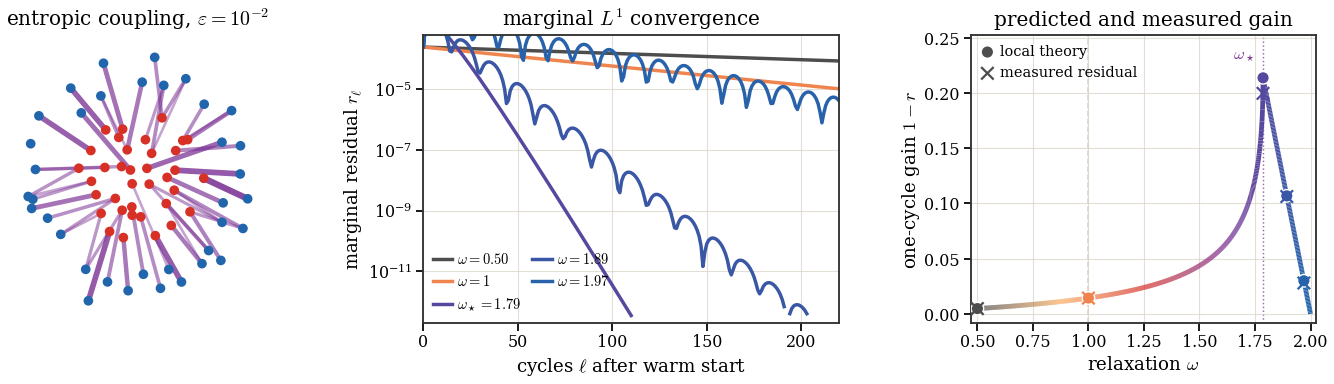

In [9]:
from IPython.display import Image, display

thumbnail = ROOT / "notebooks-figures" / "thumbnails" / "sinkhorn-overrelaxation.png"
if thumbnail.exists():
    display(Image(filename=str(thumbnail)))
else:
    print("The thumbnail is generated by the rendering cell above.")